In [27]:
# !pip install sklearn joblib imbalanced-learn numpy pandas


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline

In [ ]:
# ==========================================
# 1. CẤU HÌNH & LOAD DỮ LIỆU
# ==========================================
# Định nghĩa nhóm (Tùy chỉnh nếu dữ liệu của bạn khác)
LOW_LEVELS = ['Remember', 'Understand']
HIGH_LEVELS = ['Apply', 'Analyze', 'Evaluate', 'Create']

try:
    df = pd.read_csv(r"merged.csv")
except FileNotFoundError:
    print("❌ Không tìm thấy file! Đang tạo data giả lập...")
    df = pd.DataFrame(np.random.rand(1000, 10), columns=[f'feat_{i}' for i in range(10)])
    df['Bloom_Label'] = np.random.choice(LOW_LEVELS + HIGH_LEVELS, 1000)

if "id" in df.columns:
    df = df.drop(columns=["id"])

X = df.drop(columns=["Bloom_Label"])
y = df["Bloom_Label"]

# Chia tập Train/Test (Giữ nguyên tỉ lệ stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"📊 Train: {X_train.shape} | Test: {X_test.shape}")

# ==========================================
# 2. GIAI ĐOẠN 1: PHÂN LOẠI LOW vs HIGH (BINARY)
# ==========================================
print("\n🚀 [STAGE 1] Huấn luyện Binary Classifier (Low vs High)...")

# Tạo nhãn Binary: 0 = Low, 1 = High
y_train_bin = y_train.apply(lambda x: 0 if x in LOW_LEVELS else 1)
y_test_bin = y_test.apply(lambda x: 0 if x in LOW_LEVELS else 1)

# Pipeline cho Binary Model (Thường không cần SMOTE nặng ở đây vì tỉ lệ Low/High khá ổn)
binary_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('rf_bin', RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, n_jobs=-1))
])

binary_pipeline.fit(X_train, y_train_bin)

# Đánh giá sơ bộ Stage 1
bin_acc = accuracy_score(y_test_bin, binary_pipeline.predict(X_test))
print(f"✅ Độ chính xác phân loại Low/High: {bin_acc:.4f}")

📊 Train: (2462, 143) | Test: (616, 143)

🚀 [STAGE 1] Huấn luyện Binary Classifier (Low vs High)...
✅ Độ chính xác phân loại Low/High: 0.8653


In [30]:
# ==========================================
# 3. GIAI ĐOẠN 2: CÁC MODEL CON (SPECIALISTS)
# ==========================================

# --- 3.1 Model cho nhóm LOW (Remember, Understand) ---
print("\n🔹 [STAGE 2.1] Huấn luyện Low-Level Specialist...")
mask_low = y_train.isin(LOW_LEVELS)
X_train_low = X_train[mask_low]
y_train_low = y_train[mask_low]

le_low = LabelEncoder()
y_train_low_enc = le_low.fit_transform(y_train_low)

# Pipeline cho Low Model
low_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    # Nhóm này thường nhiều dữ liệu, dùng RF bình thường
    ('rf_low', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1))
])
low_pipeline.fit(X_train_low, y_train_low_enc)


# --- 3.2 Model cho nhóm HIGH (Apply -> Create) ---
print("🔸 [STAGE 2.2] Huấn luyện High-Level Specialist (Có SMOTE)...")
mask_high = y_train.isin(HIGH_LEVELS)
X_train_high = X_train[mask_high]
y_train_high = y_train[mask_high]

le_high = LabelEncoder()
y_train_high_enc = le_high.fit_transform(y_train_high)

# Pipeline cho High Model - QUAN TRỌNG: Dùng SMOTE ở đây
high_pipeline = ImbPipeline([
    ('scaler', StandardScaler()),
    ('smote', SMOTE(random_state=42, k_neighbors=2)), # Cân bằng dữ liệu cho nhóm khó
    ('rf_high', RandomForestClassifier(
        n_estimators=300,       # Cần nhiều cây hơn
        max_depth=None,         # Để cây mọc sâu bắt pattern khó
        class_weight='balanced', # Hỗ trợ thêm trọng số
        random_state=42, 
        n_jobs=-1
    ))
])
high_pipeline.fit(X_train_high, y_train_high_enc)

# Kiểm tra hiệu quả SMOTE
y_res_check = high_pipeline.named_steps['smote'].fit_resample(X_train_high, y_train_high_enc)[1]
print(f"   -> Số lượng mẫu nhánh High sau SMOTE: {len(y_res_check)} (Đã cân bằng)")

# ==========================================
# 4. HÀM DỰ ĐOÁN TỔNG HỢP
# ==========================================
def hierarchical_predict(X_input):
    # Bước 1: Dự đoán Binary
    binary_preds = binary_pipeline.predict(X_input)
    
    final_preds = []
    
    # Bước 2: Routing (Điều hướng)
    # Lưu ý: Dự đoán từng dòng sẽ hơi chậm, nhưng an toàn về logic
    for i in range(len(X_input)):
        row = X_input.iloc[[i]] # Lấy 1 dòng dưới dạng DataFrame
        pred_bin = binary_preds[i]
        
        if pred_bin == 0: # Nhóm Low
            pred_idx = low_pipeline.predict(row)[0]
            label = le_low.inverse_transform([pred_idx])[0]
        else: # Nhóm High
            pred_idx = high_pipeline.predict(row)[0]
            label = le_high.inverse_transform([pred_idx])[0]
            
        final_preds.append(label)
        
    return np.array(final_preds)


🔹 [STAGE 2.1] Huấn luyện Low-Level Specialist...
🔸 [STAGE 2.2] Huấn luyện High-Level Specialist (Có SMOTE)...
   -> Số lượng mẫu nhánh High sau SMOTE: 840 (Đã cân bằng)



🧪 ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP
✅ Accuracy: 0.7646103896103896

📄 Classification Report:
              precision    recall  f1-score   support

     Analyze       0.89      0.28      0.42        29
       Apply       0.88      0.88      0.88        25
      Create       0.92      0.21      0.34        53
    Evaluate       1.00      0.24      0.38        21
    Remember       0.96      0.56      0.71       135
  Understand       0.72      0.99      0.83       353

    accuracy                           0.76       616
   macro avg       0.89      0.53      0.59       616
weighted avg       0.81      0.76      0.73       616



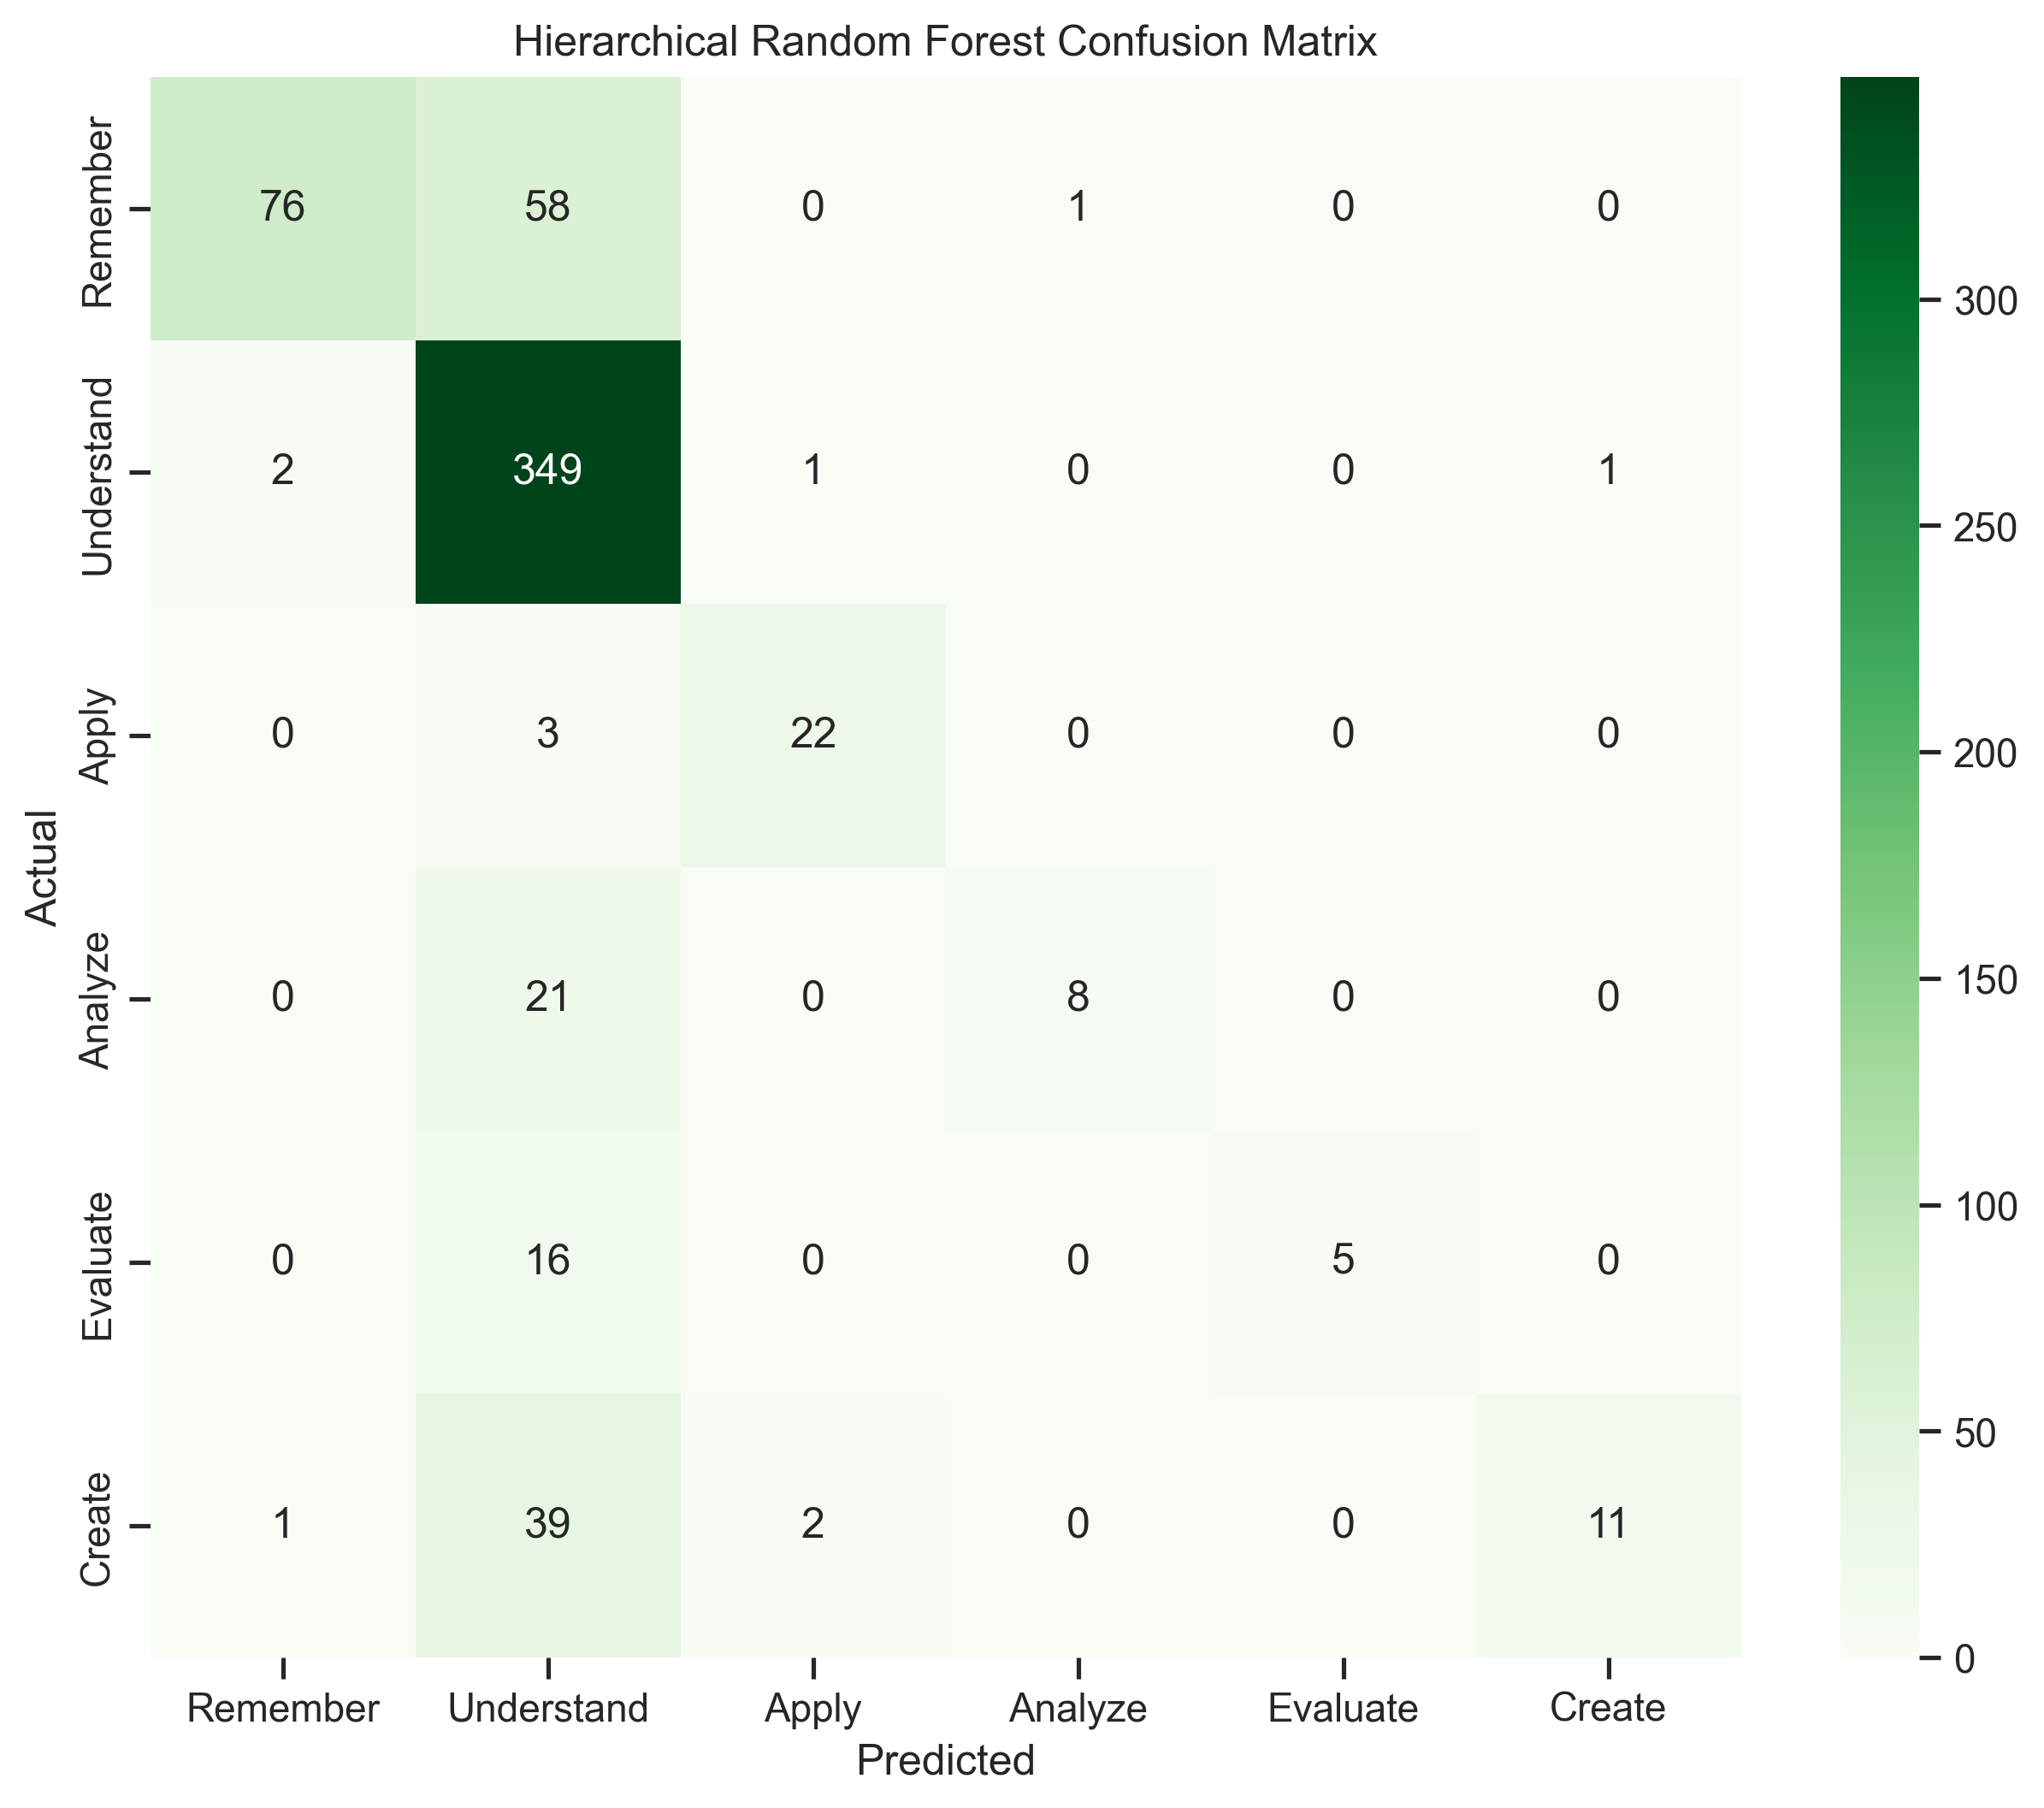

C:\Users\quang\AppData\Local\Temp\ipykernel_20532\3114516312.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')


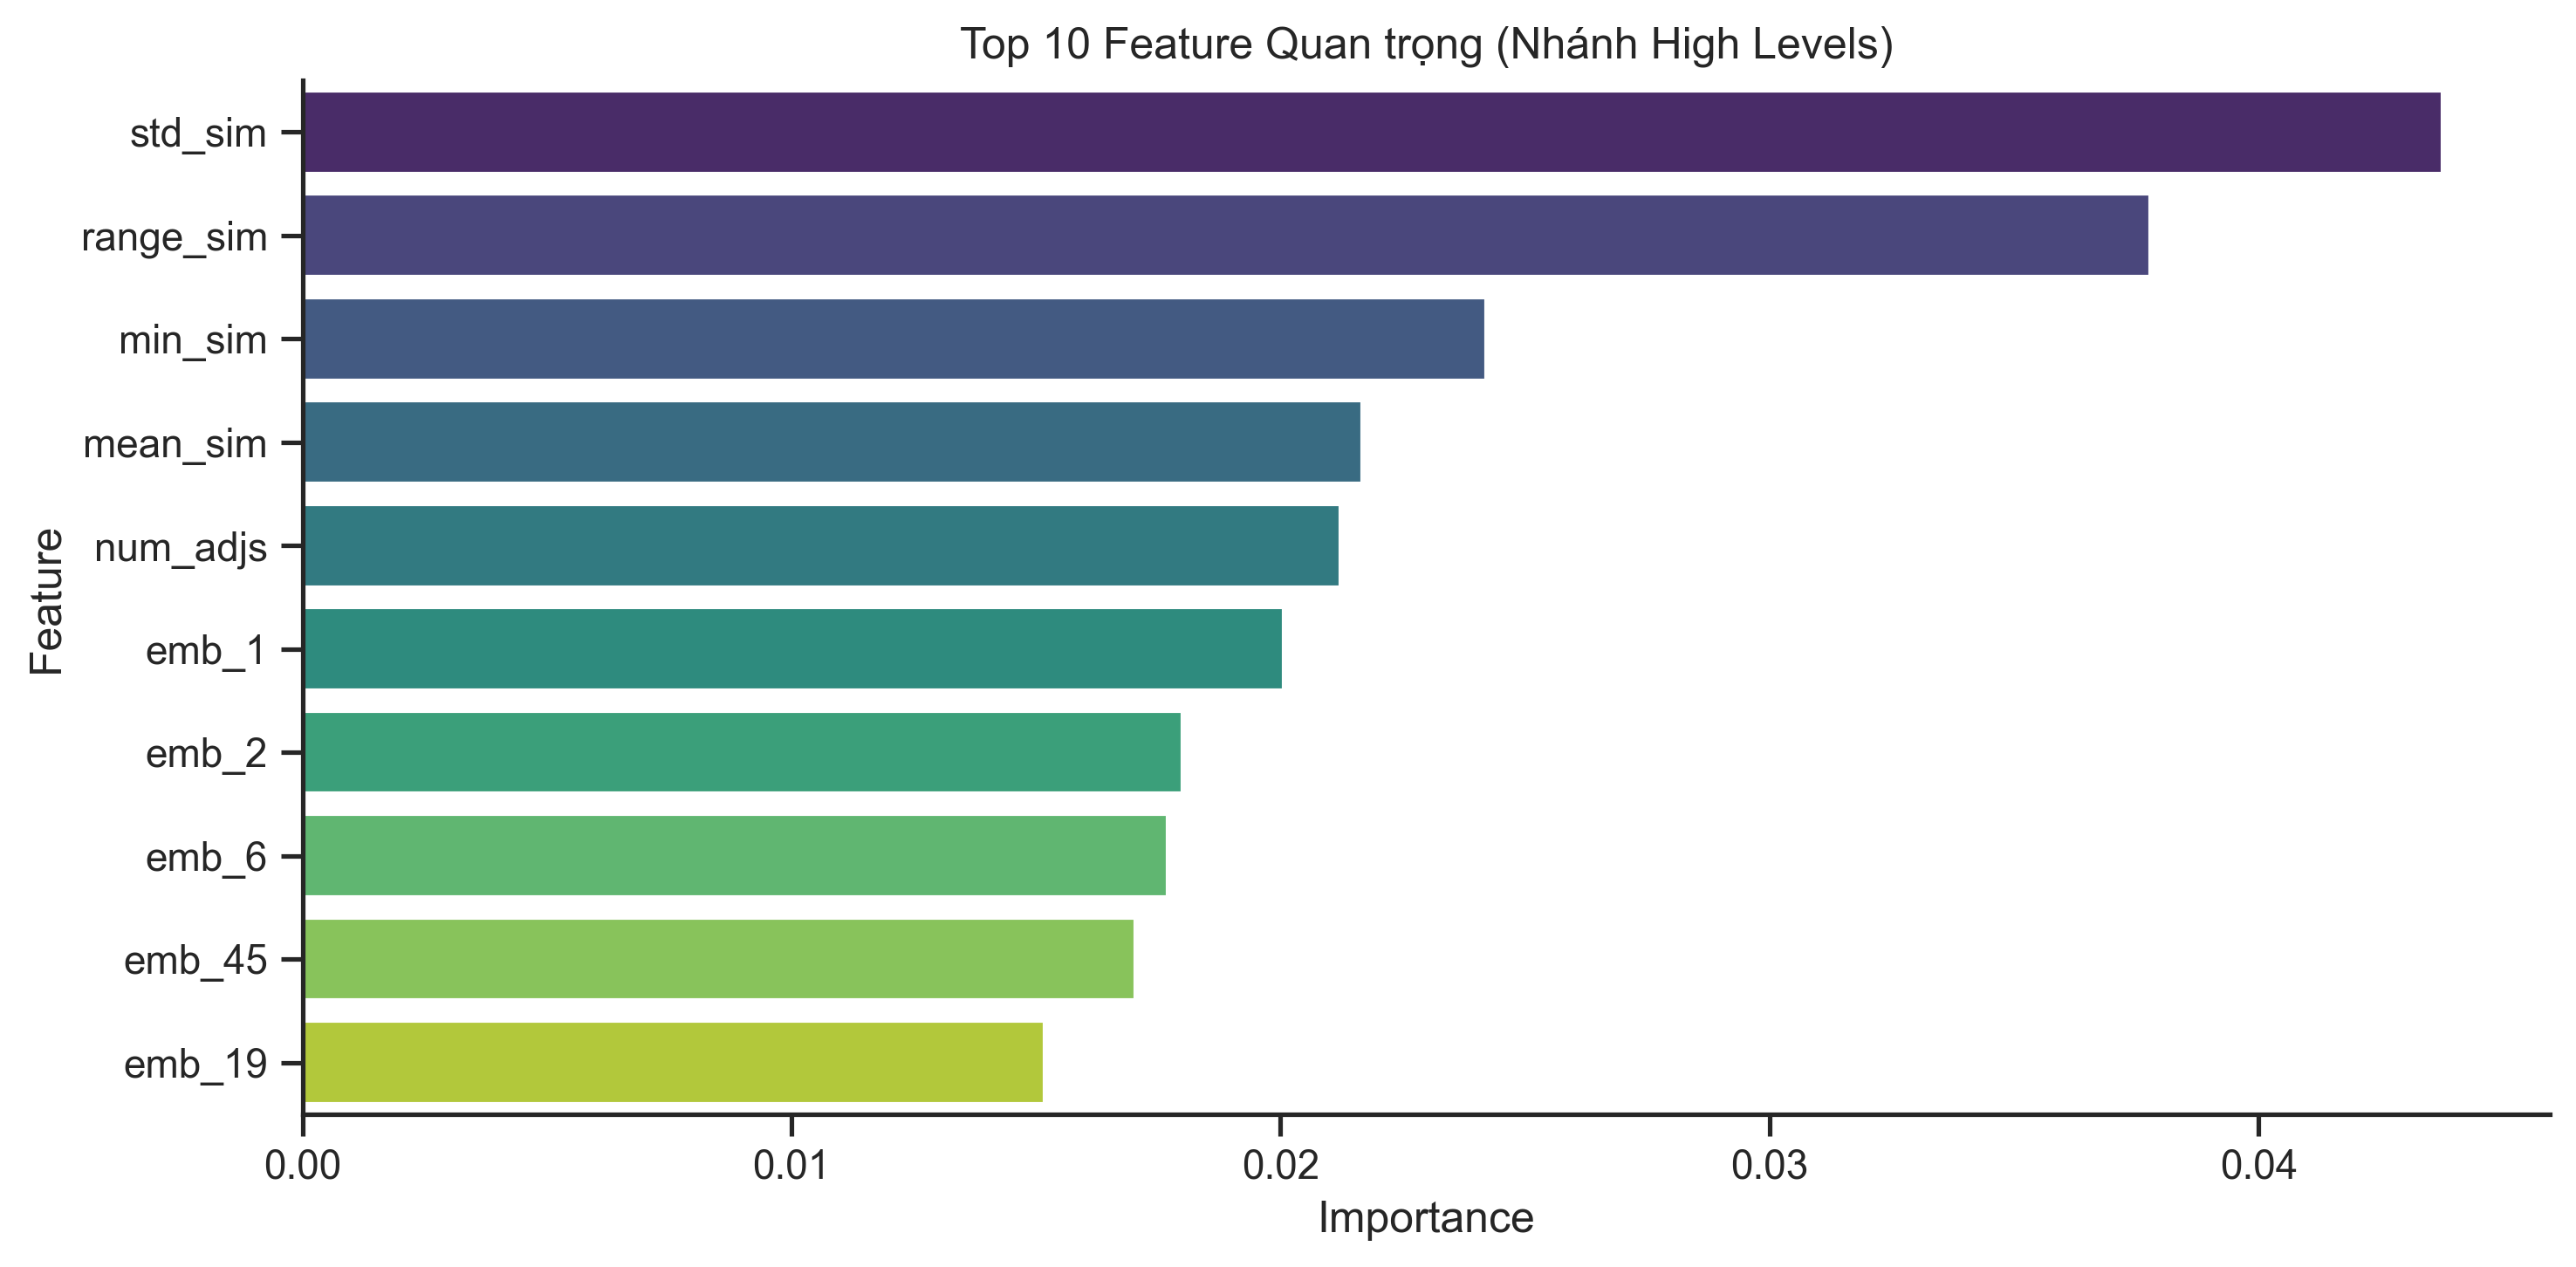

In [31]:
# ==========================================
# 5. ĐÁNH GIÁ KẾT QUẢ
# ==========================================
print("\n" + "="*30)
print("🧪 ĐÁNH GIÁ TRÊN TẬP TEST ĐỘC LẬP")
print("="*30)

y_pred_final = hierarchical_predict(X_test)

print("✅ Accuracy:", accuracy_score(y_test, y_pred_final))
print("\n📄 Classification Report:")
print(classification_report(y_test, y_pred_final))

# Vẽ Confusion Matrix
labels_order = LOW_LEVELS + HIGH_LEVELS
cm = confusion_matrix(y_test, y_pred_final, labels=labels_order)
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=labels_order, yticklabels=labels_order)
plt.title('Hierarchical Random Forest Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# ==========================================
# 6. FEATURE IMPORTANCE (CHỈ XEM CỦA NHÁNH KHÓ)
# ==========================================
# Xem feature nào quan trọng nhất để phân biệt các câu hỏi khó
rf_high = high_pipeline.named_steps['rf_high']
importances = rf_high.feature_importances_
feature_names = X.columns

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values(by='Importance', ascending=False).head(10)

plt.figure(figsize=(10, 5))
sns.barplot(x='Importance', y='Feature', data=fi_df, palette='viridis')
plt.title('Top 10 Feature Quan trọng (Nhánh High Levels)')
plt.tight_layout()
plt.show()


🧠 2. GIẢI MÃ SHAP - RANDOM FOREST (ROBUST FIX)

🅰️ [Chart A] High Levels Drivers (RF)...
   ⏳ Đang tính SHAP cho rf_high... (Vui lòng đợi)


<Figure size 3000x2100 with 0 Axes>

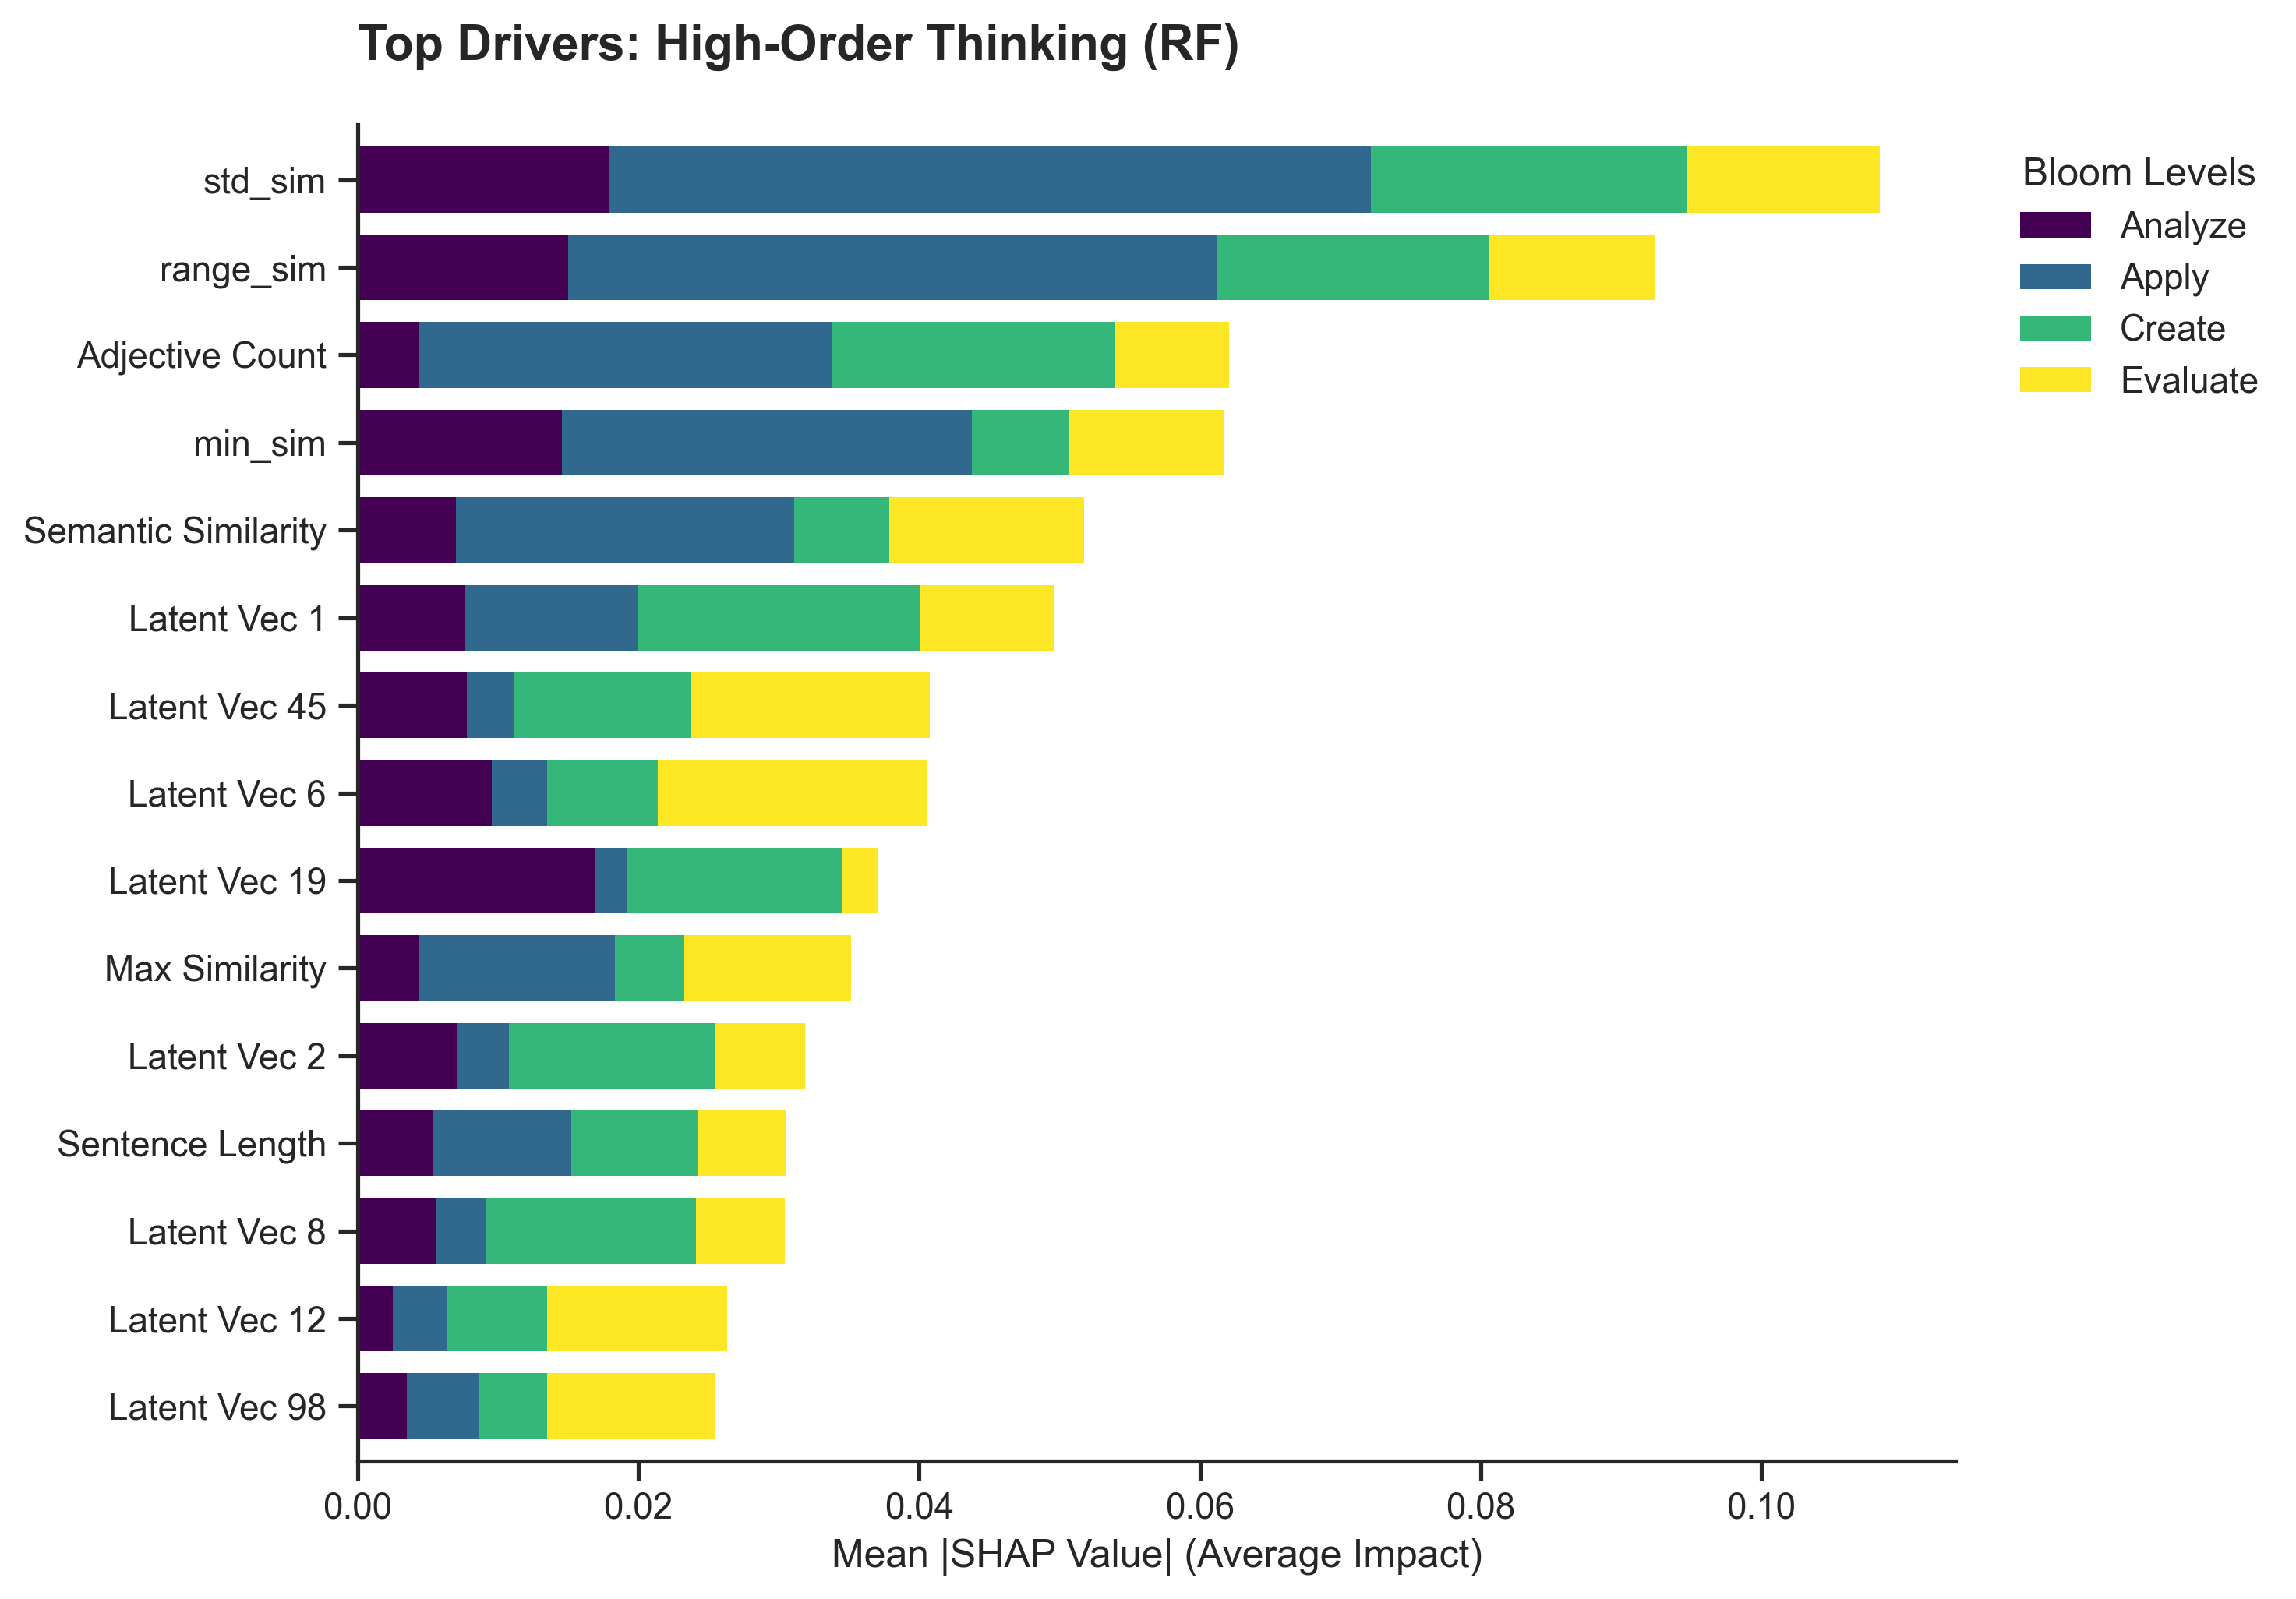


🅱️ [Chart B] Low Levels Drivers (RF)...
   ⏳ Đang tính SHAP cho rf_low... (Vui lòng đợi)


<Figure size 3000x2100 with 0 Axes>

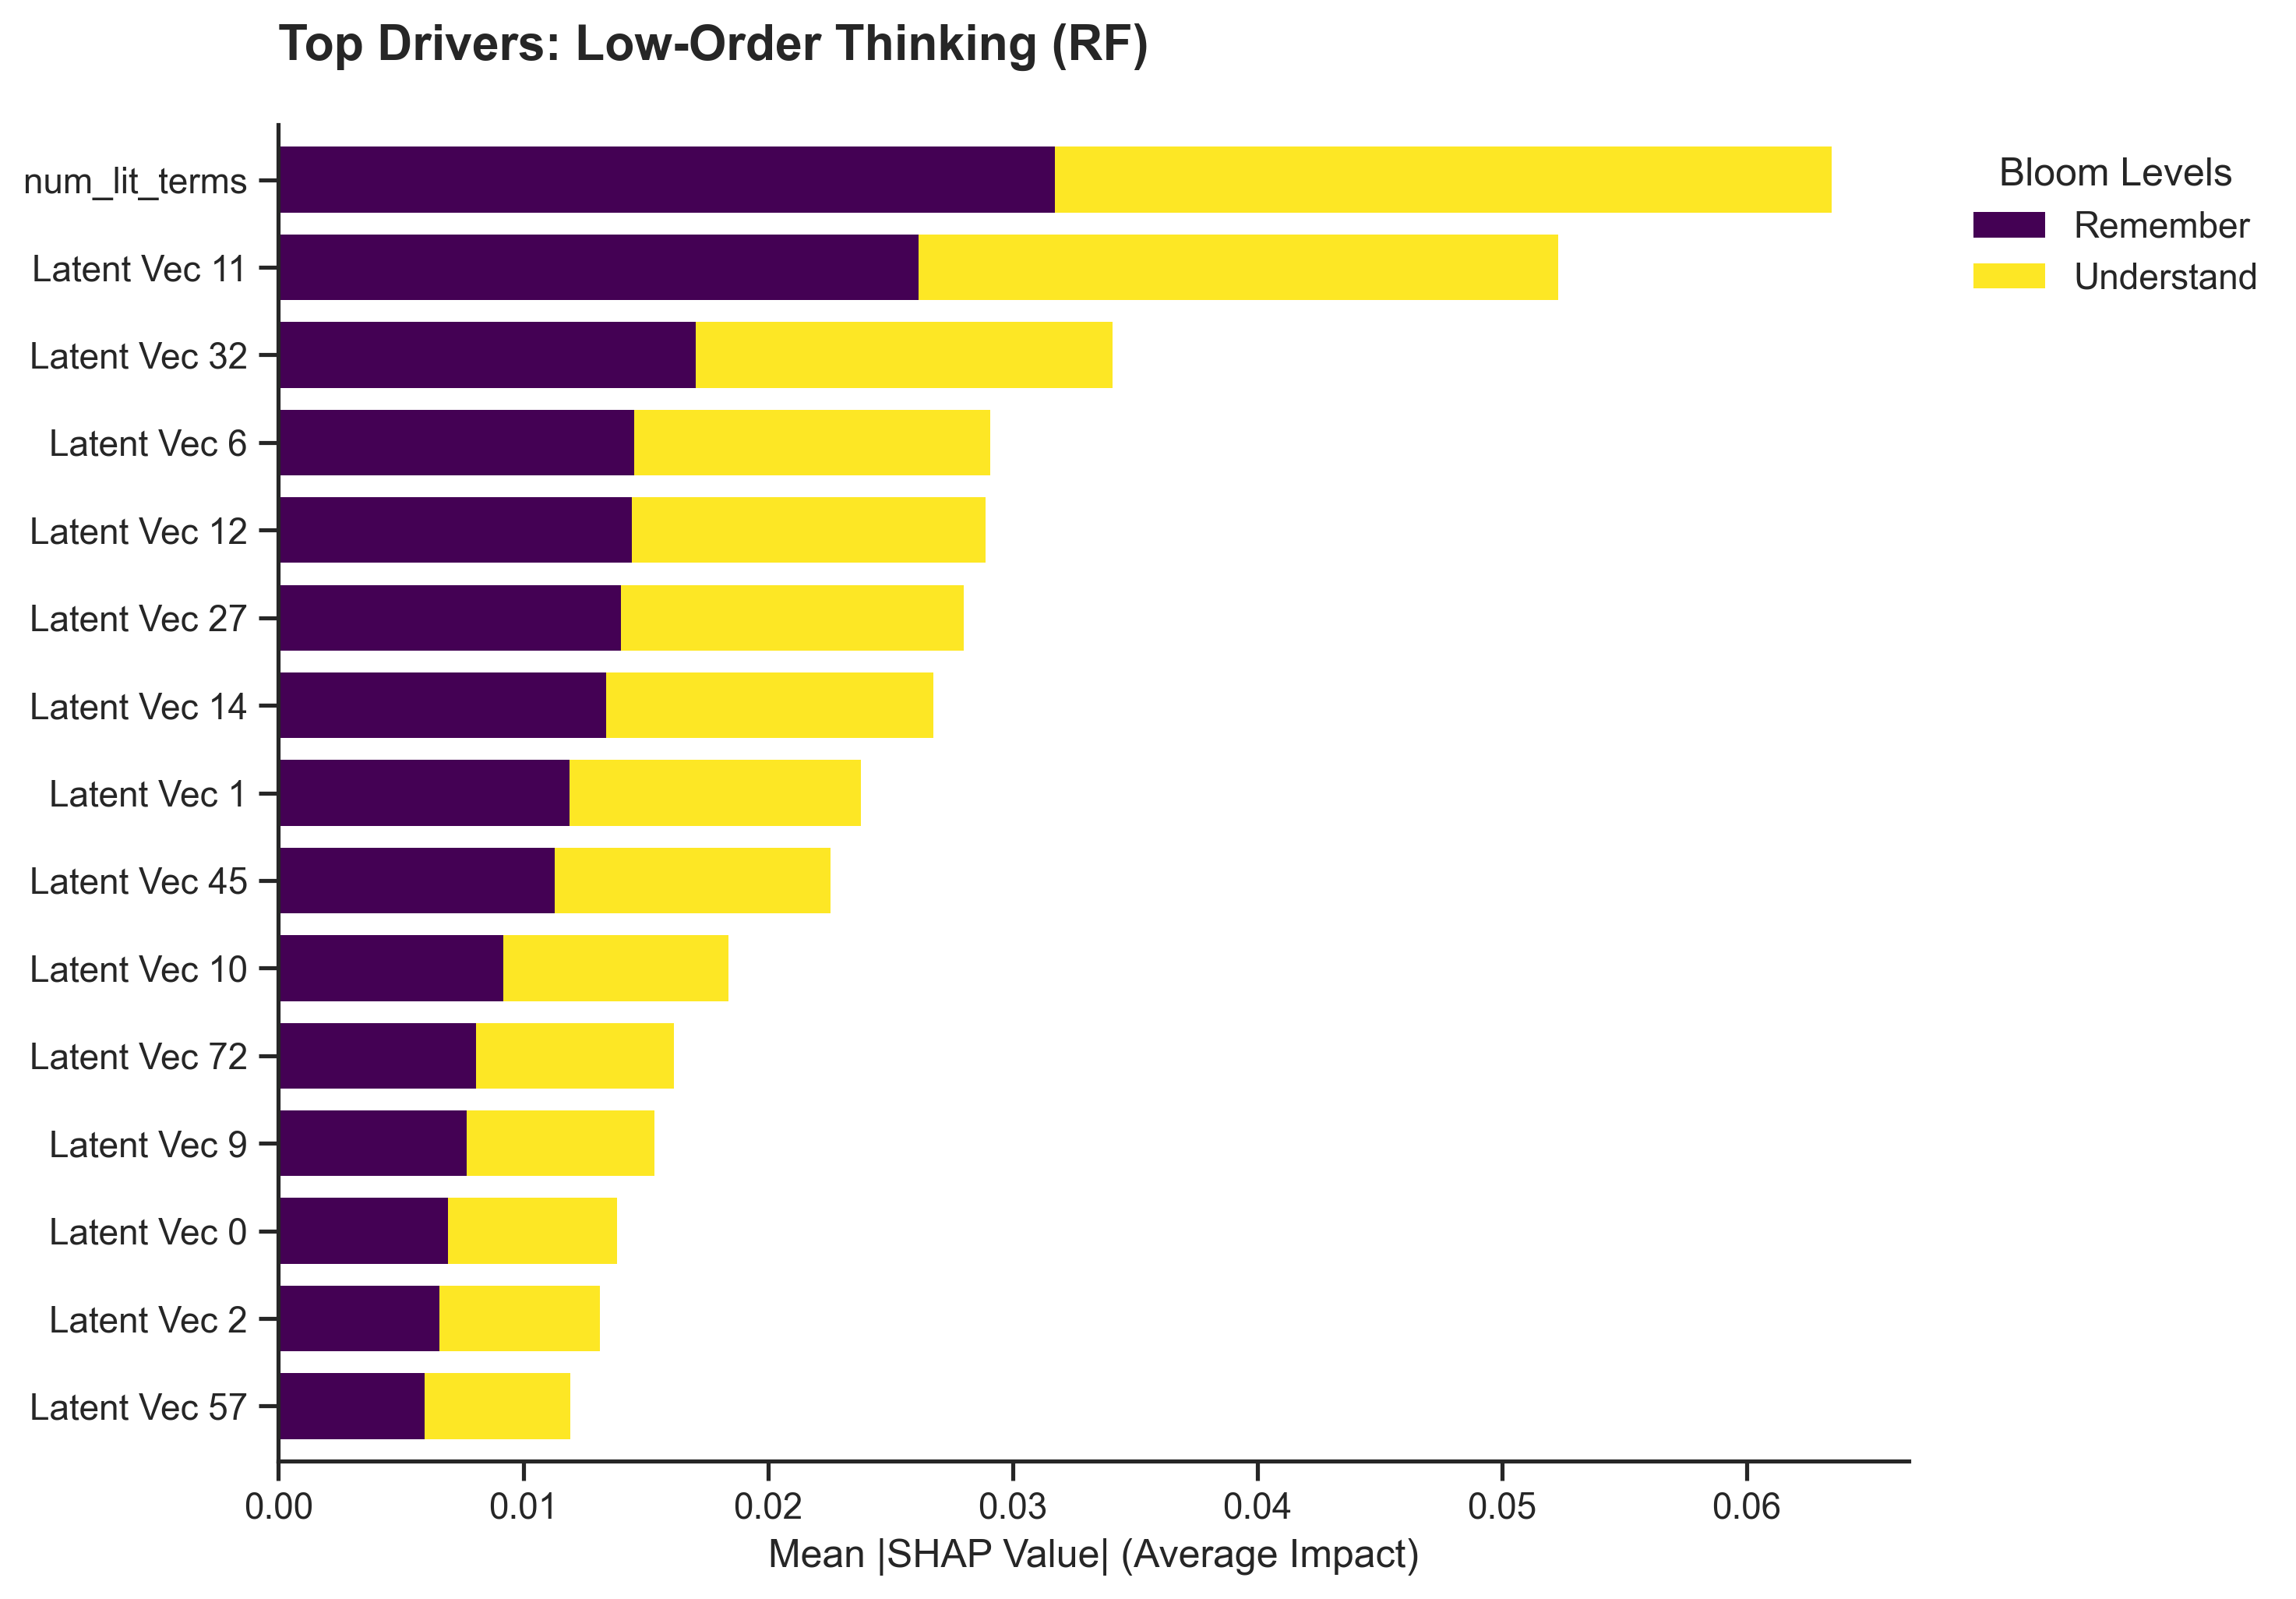


©️ [Chart C] Detailed Direction for 'Create' (RF)...
   ⏳ Đang tính SHAP cho rf_high... (Vui lòng đợi)


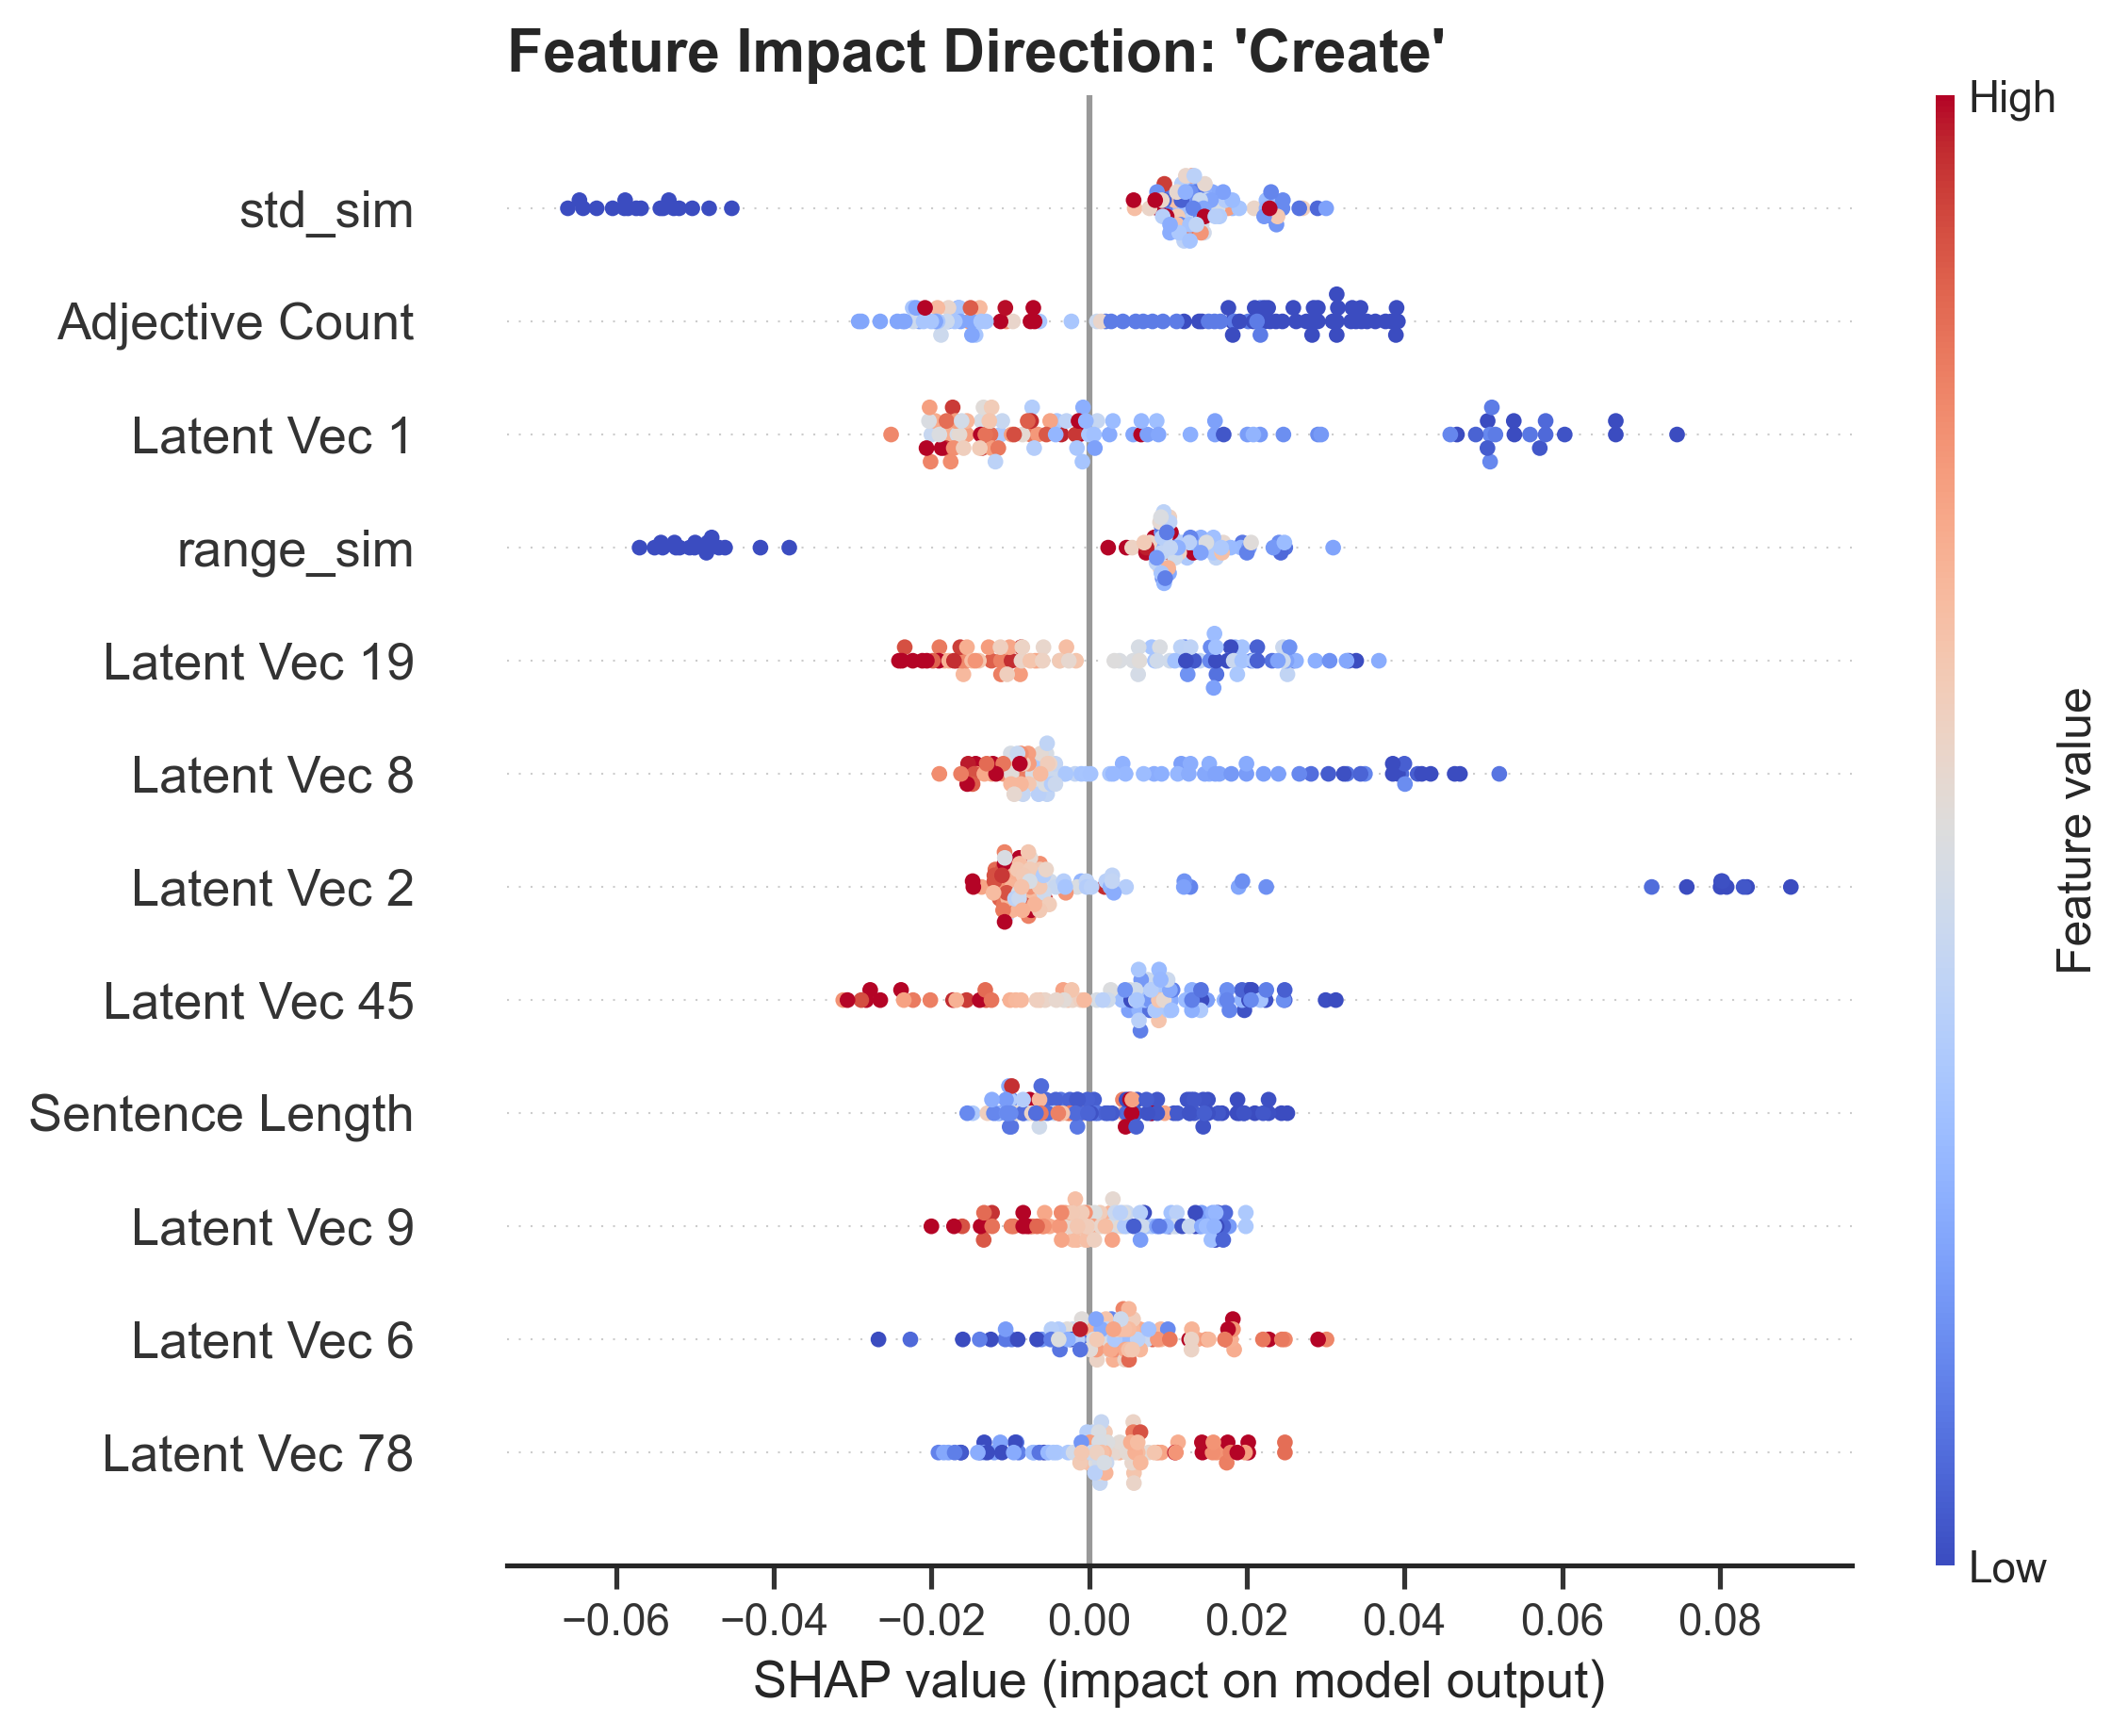

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import matplotlib.patches as mpatches

# ==============================================================================
# PHẦN 2: GIẢI MÃ SHAP CHO RANDOM FOREST (PHIÊN BẢN FIX LỖI DIMENSION)
# ==============================================================================
print("\n" + "="*40)
print("🧠 2. GIẢI MÃ SHAP - RANDOM FOREST (ROBUST FIX)")
print("="*40)

# 1. CẤU HÌNH GIAO DIỆN
sns.set_theme(style="ticks")
plt.rcParams['figure.dpi'] = 300
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 2. TỪ ĐIỂN ĐỔI TÊN FEATURE
feature_map = {
    'mean_sim': 'Semantic Similarity',
    'max_sim': 'Max Similarity',
    'mean_jaccard_sim': 'Lexical Overlap',
    'sentence_length': 'Sentence Length',
    'perplexity': 'Text Complexity (PPL)',
    'num_clauses': 'Clause Count',
    'num_verbs': 'Verb Count',
    'num_adjs': 'Adjective Count',
    'is_Compare': 'Type: Comparison',
    'is_Why': 'Type: Why-Question'
}

def beautify_feature_names(df, mapping):
    new_cols = []
    for col in df.columns:
        if col in mapping:
            new_cols.append(mapping[col])
        elif col.startswith('emb_'):
            new_cols.append(col.replace('emb_', 'Latent Vec '))
        else:
            new_cols.append(col)
    return new_cols

# --- HÀM TÍNH SHAP CHO PIPELINE RANDOM FOREST ---
def calculate_rf_shap(pipeline_model, step_name, X_data, le_encoder):
    if len(X_data) > 100: 
        X_sample = X_data.sample(100, random_state=42)
    else: 
        X_sample = X_data
    
    # Scale dữ liệu
    if 'scaler' in pipeline_model.named_steps:
        X_transformed = pipeline_model.named_steps['scaler'].transform(X_sample)
        X_transformed = pd.DataFrame(X_transformed, columns=X_sample.columns)
    else:
        X_transformed = X_sample

    model_rf = pipeline_model.named_steps[step_name]
    
    print(f"   ⏳ Đang tính SHAP cho {step_name}... (Vui lòng đợi)")
    explainer = shap.TreeExplainer(model_rf)
    shap_values = explainer.shap_values(X_transformed, check_additivity=False)
    
    return shap_values, X_sample, list(le_encoder.classes_)

# --- HÀM VẼ STACKED BAR (CHART A & B) ---
def plot_rf_stacked_bar(pipeline, step_name, X_data, le_encoder, title, cmap_name='viridis'):
    shap_values, X_sample, class_names = calculate_rf_shap(pipeline, step_name, X_data, le_encoder)
    
    feature_names = beautify_feature_names(X_sample, feature_map)
    df_imp = pd.DataFrame(index=feature_names)
    
    # --- LOGIC SỬA LỖI: Xử lý List vs Array 3D ---
    for i, c_name in enumerate(class_names):
        sv = None
        
        # Case 1: SHAP là List (Mỗi phần tử là matrix của 1 class)
        if isinstance(shap_values, list):
            sv = shap_values[i]
            
        # Case 2: SHAP là Array 3 chiều (Samples, Features, Classes)
        elif len(np.array(shap_values).shape) == 3:
            # Lấy lát cắt theo chiều cuối cùng (Classes)
            # Kiểm tra xem chiều nào khớp với số class
            shape = np.array(shap_values).shape
            if shape[2] == len(class_names):
                sv = shap_values[:, :, i]
            elif shape[0] == len(class_names): # Hiếm gặp nhưng phòng hờ
                sv = shap_values[i, :, :]
                
        # Case 3: Binary Model (Array 2 chiều)
        else:
            sv = shap_values # Chỉ có 1 mảng cho class 1
            
        # Phòng vệ: Nếu sv vẫn chưa đúng định dạng (Samples, Features)
        if sv is None: continue
            
        # Tính Mean Abs
        mean_abs = np.mean(np.abs(sv), axis=0)
        
        # Gán vào DataFrame (Đảm bảo độ dài khớp)
        if len(mean_abs) == len(feature_names):
            df_imp[c_name] = mean_abs
        else:
            # Nếu dư cột bias, cắt bớt
            df_imp[c_name] = mean_abs[:len(feature_names)]

    # Sắp xếp và lấy Top 15
    df_imp['Total'] = df_imp.sum(axis=1)
    df_imp = df_imp.sort_values(by='Total', ascending=True).tail(15)
    df_plot = df_imp.drop(columns=['Total'])
    
    # Vẽ
    plt.figure(figsize=(10, 7))
    ax = df_plot.plot(kind='barh', stacked=True, figsize=(10, 7), 
                      colormap=cmap_name, width=0.75, edgecolor='none')
    
    plt.title(title, fontsize=15, fontweight='bold', loc='left', pad=20)
    plt.xlabel('Mean |SHAP Value| (Average Impact)', fontsize=12)
    plt.yticks(fontsize=11)
    plt.legend(title="Bloom Levels", bbox_to_anchor=(1.02, 1), loc='upper left', frameon=False)
    plt.tight_layout()
    plt.show()

# --- HÀM VẼ BEESWARM (CHART C) ---
def plot_rf_beeswarm(pipeline, step_name, X_data, le_encoder, target_class):
    shap_values, X_sample, class_names = calculate_rf_shap(pipeline, step_name, X_data, le_encoder)
    
    if target_class not in class_names:
        print(f"❌ Không tìm thấy lớp {target_class}")
        return

    idx = class_names.index(target_class)
    
    # --- LOGIC SỬA LỖI TƯƠNG TỰ ---
    sv_target = None
    if isinstance(shap_values, list):
        sv_target = shap_values[idx]
    elif len(np.array(shap_values).shape) == 3:
        sv_target = shap_values[:, :, idx]
    else:
        sv_target = shap_values

    # Đổi tên feature data
    X_display = pd.DataFrame(X_sample.values, columns=beautify_feature_names(X_sample, feature_map))
    
    # Fix shape mismatch (bias column)
    if sv_target.shape[1] != X_display.shape[1]:
        sv_target = sv_target[:, :X_display.shape[1]]

    plt.figure(figsize=(10, 6))
    shap.summary_plot(sv_target, X_display, max_display=12, show=False, cmap="coolwarm")
    plt.title(f"Feature Impact Direction: '{target_class}'", fontsize=15, fontweight='bold', loc='left')
    plt.tight_layout()
    plt.show()

# =========================================================
# THỰC THI
# =========================================================

# 1. CHART A
print("\n🅰️ [Chart A] High Levels Drivers (RF)...")
mask_high = y_test.isin(HIGH_LEVELS)
plot_rf_stacked_bar(
    pipeline=high_pipeline,
    step_name='rf_high',
    X_data=X_test[mask_high],
    le_encoder=le_high,
    title="Top Drivers: High-Order Thinking (RF)",
    cmap_name="viridis"
)

# 2. CHART B
print("\n🅱️ [Chart B] Low Levels Drivers (RF)...")
mask_low = y_test.isin(LOW_LEVELS)
plot_rf_stacked_bar(
    pipeline=low_pipeline,
    step_name='rf_low',
    X_data=X_test[mask_low],
    le_encoder=le_low,
    title="Top Drivers: Low-Order Thinking (RF)",
    cmap_name="viridis"
)

# 3. CHART C
print("\n©️ [Chart C] Detailed Direction for 'Create' (RF)...")
mask_high = y_test.isin(HIGH_LEVELS)
plot_rf_beeswarm(
    pipeline=high_pipeline,
    step_name='rf_high',
    X_data=X_test[mask_high],
    le_encoder=le_high,
    target_class="Create"
)